## **Finetuning Qwen3 8B with Unsloth**


LLM: given tokens -> predict next token
Fine-tuning: Change the weights of how LLM predict next token by providing it examples of "this text" -> "followed by this text"

1. Load source/target pairs
2. Turn each pair into a long string which is how Qwen sees it
3. Tell trainer to only learn from brainrot answer part (second part)
4. Run training loop
5. Save adapter

In [12]:
# 2. Get repo (Colab only)
%cd /content
!git clone -b finetune/qlora https://github.com/PrimitivePenguin/StormHack2026.git || (cd StormHack2026 && git pull)
%cd /content/StormHack2026/src_brainrot/1_LLM_finetune

/content
fatal: destination path 'StormHack2026' already exists and is not an empty directory.
remote: Enumerating objects: 15, done.
remote: Counting objects: 100% (15/15), done.
remote: Compressing objects: 100% (6/6), done.
remote: Total 9 (delta 6), reused 4 (delta 3), pack-reused 0 (from 0)
Unpacking objects: 100% (9/9), 15.62 KiB | 231.00 KiB/s, done.
From https://github.com/PrimitivePenguin/StormHack2026
   e414ec6..06baf46  main       -> origin/main
Already up to date.
/content/StormHack2026/src_brainrot/1_LLM_finetune


In [13]:
# 3. Install unsloth
%pip install unsloth
# %%capture

In [14]:
# 4. Import, path, save
# import models
import sys
from pathlib import Path

ROOT = Path("../..").resolve()
sys.path.append(str(ROOT / "src_brainrot"))

from unsloth import FastLanguageModel
from unsloth.chat_templates import train_on_responses_only

from trl import SFTTrainer, SFTConfig
from datasets import load_dataset

SYSTEM_PROMPT = "Rewrite the user's text in Gen-Z brainrot slang. Keep the meaning."
MODEL = "unsloth/Qwen3-4B-unsloth-bnb-4bit"
# from shared import SYSTEM_PROMPT, MODEL

# On Colab save to Drive to disconnect doesn't lose work
try:
    from google.colab import drive
    drive.mount("/content/drive")
    SAVE = Path("/content/drive/MyDrive/brainrot")
except ImportError:
      SAVE = Path("./brainrot")

import torch

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [15]:
# 5. Load model and tokenizer
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = MODEL,
    max_seq_length = 256,
    load_in_4bit = True,
)

==((====))==  Unsloth 2026.9.14: Fast Qwen3 patching. Transformers: 5.17.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu130. CUDA: 7.5. CUDA Toolkit: 13.0. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

In [16]:
# 6. attach LoRA
model = FastLanguageModel.get_peft_model(
    model,
    r = 16,
    target_modules = ["q_proj", "k_proj", "v_proj", "o_proj",
                      "gate_proj", "up_proj", "down_proj"],
    lora_alpha = 16,
    lora_dropout = 0,
    bias = "none",
    use_gradient_checkpointing = "unsloth",
    random_state = 3407,
)

In [17]:
# 7. load dataset
ds = load_dataset("json", data_files={"train": str (ROOT / "data/train.jsonl"), "val": str(ROOT / "data/val.jsonl")})

# format: list of 3 dicts is standard format openAI, Gemini, and others use
# Given row, format a three-msg conversation
#   system: SYSTEM_PROMPT
#   user: row["source"] Ex. "Why am I like this?"
#   assistant: row["target"] Ex. "system error: brain.exe encountered feelings again"
# tokenizer.apply_chat_template() format into raw string Qwen was trained on
def format(row): # given a row, format such that
    msgs = [{"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": row["source"]},
            {"role": "assistant", "content": row["target"]}]
    return {"text": tokenizer.apply_chat_template(msgs, tokenize=False, enable_thinking=False)}

# map the format to all rows in dataset
ds = ds.map(format)

Map:   0%|          | 0/1593 [00:00<?, ? examples/s]

Map:   0%|          | 0/163 [00:00<?, ? examples/s]

In [18]:
# 8. Set up training
trainer = SFTTrainer(
    model = model,                      # model to train on
    processing_class = tokenizer,       # tokenizer: text -> token ID
    train_dataset = ds["train"],
    eval_dataset = ds["val"],           # data
    args = SFTConfig(
        dataset_text_field = "text",    # field in dataset to use for training
        per_device_train_batch_size = 2,
        gradient_accumulation_steps = 4,
        num_train_epochs = 2,
        learning_rate = 2e-4,
        warmup_steps = 10,
        eval_strategy = "steps", eval_steps = 50,
        logging_steps = 10,
        optim="adamw_8bit",
        seed = 42,
        output_dir = str (SAVE / "outputs/checkpoints"),
        save_steps = 100,
        save_total_limit = 2,
    )
)

Unsloth: Tokenizing ["text"] (num_proc=2):   0%|          | 0/1593 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=2):   0%|          | 0/163 [00:00<?, ? examples/s]

🦥 Unsloth: Padding-free auto-enabled, enabling faster training.


In [19]:
# 9. train answers only
trainer = train_on_responses_only(
    trainer,
    instruction_part="<|im_start|>user\n",
    response_part="<|im_start|>assistant\n",
)
trainer.train()

print(torch.cuda.max_memory_reserved() / 1e9, "GB")

Map:   0%|          | 0/1593 [00:00<?, ? examples/s]

Map:   0%|          | 0/163 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 1,593 | Num Epochs = 2 | Total steps = 400
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 33,030,144 of 4,055,498,240 (0.81% trained)


Step,Training Loss,Validation Loss
50,2.565741,2.476094
100,2.269211,2.298136
150,2.093294,2.183641
200,2.399335,2.117814
250,1.638490,2.098294
300,1.540905,2.083349
350,1.676632,2.050969
400,1.548470,2.052268


Filter:   0%|          | 0/163 [00:00<?, ? examples/s]

Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/brainrot/outputs/checkpoints/checkpoint-100/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/brainrot/outputs/checkpoints/checkpoint-200/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/brainrot/outputs/checkpoints/checkpoint-300/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/brainrot/outputs/checkpoints/checkpoint-400/tokenizer_config.json.


12.301893632 GB


In [20]:
# 10. Save adapter
model.save_pretrained(SAVE / "brainrot_lora")
tokenizer.save_pretrained(SAVE / "brainrot_lora")

Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/brainrot/brainrot_lora/tokenizer_config.json.


('/content/drive/MyDrive/brainrot/brainrot_lora/tokenizer_config.json',
 '/content/drive/MyDrive/brainrot/brainrot_lora/chat_template.jinja',
 '/content/drive/MyDrive/brainrot/brainrot_lora/tokenizer.json')

In [21]:
# 11. Test it minor
FastLanguageModel.for_inference(model)

for text in ["I need to finish my homework before dinner.",
             "The weather is really nice today.",
             "I'm tired, I'm going to sleep."]:
    msgs = [{"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": text}]
    inputs = tokenizer.apply_chat_template(
        msgs, add_generation_prompt=True, enable_thinking=False, return_tensors="pt"
    ).to("cuda")
    out = model.generate(input_ids=inputs, max_new_tokens=64, temperature=0.8, do_sample=True)
    print(text, "→", tokenizer.decode(out[0][inputs.shape[1]:], skip_special_tokens=True))

Both `max_new_tokens` (=64) and `max_length`(=40960) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=64) and `max_length`(=40960) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


I need to finish my homework before dinner. → homework before dinner? my internal clock is currently on 'urgent' mode fr 📚⏰ gotta get that done quick, struggle rn 🙏 finish the work


Both `max_new_tokens` (=64) and `max_length`(=40960) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


The weather is really nice today. → the weather is SLAPIN today? ☀️😎 nice vibe fr, feelin good rn 🙏
I'm tired, I'm going to sleep. → my eyelids are heavy as lead rn 😴 bedtime mode loading, sleep coming fast 💤


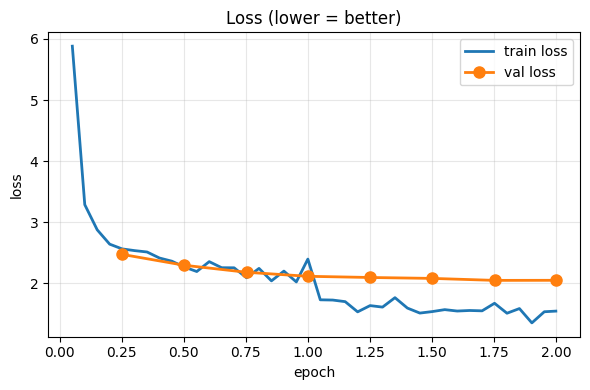

In [22]:
# 12. graph
import pandas as pd
import matplotlib.pyplot as plt

logs  = pd.DataFrame(trainer.state.log_history)
train = logs.dropna(subset=["loss"])          # rows logged every 10 steps
val   = logs.dropna(subset=["eval_loss"])     # rows logged every 50 steps

has_acc = "mean_token_accuracy" in logs
fig, axes = plt.subplots(1, 2 if has_acc else 1, figsize=(12 if has_acc else 6, 4))
ax = axes[0] if has_acc else axes

# Loss: lower is better
ax.plot(train["epoch"], train["loss"], lw=2, label="train loss")
ax.plot(val["epoch"], val["eval_loss"], lw=2, marker="o", markersize=8, label="val loss")
ax.set(title="Loss (lower = better)", xlabel="epoch", ylabel="loss")
ax.grid(alpha=0.3); ax.legend()

# Token accuracy: higher is better (only if TRL logged it)
if has_acc:
    acc = logs.dropna(subset=["mean_token_accuracy"])
    axes[1].plot(acc["epoch"], acc["mean_token_accuracy"], lw=2, label="train token accuracy")
    if "eval_mean_token_accuracy" in logs:
        vacc = logs.dropna(subset=["eval_mean_token_accuracy"])
        axes[1].plot(vacc["epoch"], vacc["eval_mean_token_accuracy"], lw=2, marker="o",
                     markersize=8, label="val token accuracy")
    axes[1].set(title="Token accuracy (higher = better)", xlabel="epoch", ylabel="accuracy")
    axes[1].grid(alpha=0.3); axes[1].legend()

plt.tight_layout(); plt.show()

In [ ]:
# 13. Load base model
# contains:
#   tokenizer.json,
#   tokenizer_config.json,
#   chat_template.jinja,
#   adapter_config.json,
#   adapter_model.safetensors

from google.colab import drive
drive.mount("/content/drive")

from unsloth import FastLanguageModel

LORA = "/content/drive/MyDrive/brainrot/brainrot_lora"   # ← your adapter folder in Drive

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = LORA,        # reads adapter_config.json → downloads the base model → attaches your adapter
    max_seq_length = 256,
    load_in_4bit = True,
)

In [ ]:
# 14. export to gguf
model.save_pretrained_gguf("/content/brainrot", tokenizer, quantization_method="q4_k_m")